In [1]:
import copy
import json
import os
import random
import time
from pathlib import Path

os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.cluster import KMeans
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.utils.data import DataLoader, Dataset


In [2]:
SEED = 42
DATASET_NAME = "FD002"
WINDOW_LENGTH = 50
TRAIN_WINDOW_STRIDE = 1
VAL_FRACTION = 0.2
RUL_CAP = 125
REGIME_COUNT = 6
NORMALIZE_TARGET = True
CLIP_PREDICTIONS_TO_CAP = True

SENSOR_COLUMNS = [
    "s4",
    "s14",
    "s11",
    "s15",
    "s9",
    "s3",
    "s13",
    "s21",
    "s2",
    "s8",
    "s7",
    "s12",
]
OP_COLUMNS = ["op1", "op2", "op3"]
INPUT_FEATURE_COLUMNS = SENSOR_COLUMNS + OP_COLUMNS
USE_REGIME_ID = True

BATCH_SIZE = 128
HIDDEN_SIZE = 40
ATTENTION_SIZE = 40
LSTM_LAYERS = 1
REGIME_EMBED_DIM = 5
HEAD_HIDDEN_SIZE = 20
DROPOUT = 0.11

LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-5
SCHEDULER_NAME = "ReduceLROnPlateau"
SCHEDULER_FACTOR = 0.5
SCHEDULER_PATIENCE = 2
SCHEDULER_THRESHOLD = 1e-4
SCHEDULER_MIN_LR = 1e-5
MAX_EPOCHS = 20
EARLY_STOPPING_PATIENCE = 5
GRAD_CLIP_NORM = 1.0

NUM_WORKERS = 0
if torch.cuda.is_available():
    DEVICE = "cuda"
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"
PIN_MEMORY = DEVICE == "cuda"

EXPERIMENT_NAME = "fd002_attention_lstm_small"
SAVE_ARTIFACTS = True


In [3]:
RAW_COLUMNS = ["unit", "cycle", "op1", "op2", "op3"] + [f"s{i}" for i in range(1, 22)]
EXPECTED_RAW_FILES = ["train_FD002.txt", "test_FD002.txt", "RUL_FD002.txt"]
OPTIONAL_PROCESSED_FILES = ["fd002_train_regimes.csv", "fd002_test_regimes.csv"]


def unique_paths(paths: list[Path]) -> list[Path]:
    unique: list[Path] = []
    seen: set[str] = set()
    for raw_path in paths:
        path = Path(raw_path).expanduser()
        try:
            resolved = path.resolve()
        except FileNotFoundError:
            resolved = path.absolute()
        key = str(resolved)
        if key in seen:
            continue
        seen.add(key)
        unique.append(resolved)
    return unique


def looks_like_project_root(path: Path) -> bool:
    if not path.exists() or not path.is_dir():
        return False

    has_repo_layout = (path / "notebooks").is_dir() and (path / "data").is_dir()
    has_raw_files = all((path / "data" / "raw" / file_name).is_file() for file_name in EXPECTED_RAW_FILES)
    has_project_markers = (path / "AGENTS.md").is_file() or (path / "requirements.txt").is_file()
    return has_raw_files or (has_repo_layout and has_project_markers)


def resolve_project_root() -> Path:
    current_dir = Path.cwd().resolve()
    for candidate in unique_paths([current_dir, *current_dir.parents]):
        if looks_like_project_root(candidate):
            return candidate

    raise FileNotFoundError(
        "Could not locate the local CMAPSS project root. Run this notebook from the "
        "repository root or a subdirectory that contains data/raw."
    )


def ensure_required_raw_files(project_root: Path) -> Path:
    raw_dir = project_root / "data" / "raw"
    missing_files = [file_name for file_name in EXPECTED_RAW_FILES if not (raw_dir / file_name).is_file()]
    if missing_files:
        missing_text = ", ".join(missing_files)
        raise FileNotFoundError(
            f"Missing required FD002 raw files in {raw_dir}: {missing_text}. "
            "Place the files under the local data/raw directory before running the notebook."
        )
    return raw_dir


def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


PROJECT_ROOT = resolve_project_root()
RAW_DIR = ensure_required_raw_files(PROJECT_ROOT)
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
ARTIFACT_DIR = PROJECT_ROOT / "artifacts" / EXPERIMENT_NAME

seed_everything(SEED)

print(f"Project root: {PROJECT_ROOT}")
print(f"Raw data directory: {RAW_DIR}")
print(f"Processed data directory: {PROCESSED_DIR}")
print(f"Device: {DEVICE}")


def load_fd002_split(split: str) -> pd.DataFrame:
    frame = pd.read_csv(RAW_DIR / f"{split}_FD002.txt", sep=r"\s+", header=None).iloc[:, :26].copy()
    frame.columns = RAW_COLUMNS
    return frame


def load_fd002_test_rul() -> pd.DataFrame:
    rul = pd.read_csv(RAW_DIR / "RUL_FD002.txt", sep=r"\s+", header=None)
    rul.columns = ["true_rul"]
    rul["unit"] = np.arange(1, len(rul) + 1)
    rul["capped_true_rul"] = rul["true_rul"].clip(upper=RUL_CAP)
    return rul


def attach_regime_ids(frame: pd.DataFrame, split: str) -> pd.DataFrame:
    regime_path = PROCESSED_DIR / f"fd002_{split}_regimes.csv"
    if not regime_path.exists():
        raise FileNotFoundError(f"{regime_path} is missing")

    regimes = pd.read_csv(regime_path)
    merged = frame.merge(regimes, on=["unit", "cycle"], how="left")
    if merged["regime_id"].isna().any():
        raise ValueError(f"Missing regime_id values after merging {regime_path.name}")
    merged["regime_id"] = merged["regime_id"].astype(int)
    return merged


def assign_regime_ids_from_operating_settings(
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    regime_count: int,
    seed: int,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    scaler = StandardScaler()
    train_ops = scaler.fit_transform(train_df[["op1", "op2", "op3"]].to_numpy(dtype=float))
    test_ops = scaler.transform(test_df[["op1", "op2", "op3"]].to_numpy(dtype=float))

    model = KMeans(n_clusters=regime_count, n_init=50, random_state=seed)
    raw_train_labels = model.fit_predict(train_ops)
    raw_test_labels = model.predict(test_ops)

    centers = pd.DataFrame(
        scaler.inverse_transform(model.cluster_centers_),
        columns=["op1", "op2", "op3"],
    )
    centers["raw_cluster"] = np.arange(len(centers))
    centers = centers.sort_values(["op1", "op2", "op3"]).reset_index(drop=True)
    centers["regime_id"] = np.arange(len(centers))
    label_map = dict(zip(centers["raw_cluster"], centers["regime_id"]))

    train_df = train_df.copy()
    test_df = test_df.copy()
    train_df["regime_id"] = pd.Series(raw_train_labels).map(label_map).astype(int).to_numpy()
    test_df["regime_id"] = pd.Series(raw_test_labels).map(label_map).astype(int).to_numpy()
    return train_df, test_df


def prepare_fd002_frames() -> tuple[pd.DataFrame, pd.DataFrame]:
    train_df = load_fd002_split("train")
    test_df = load_fd002_split("test")

    try:
        train_df = attach_regime_ids(train_df, "train")
        test_df = attach_regime_ids(test_df, "test")
        print("Loaded precomputed regime_id files from data/processed.")
    except FileNotFoundError:
        train_df, test_df = assign_regime_ids_from_operating_settings(
            train_df=train_df,
            test_df=test_df,
            regime_count=REGIME_COUNT,
            seed=SEED,
        )
        print("Precomputed regime files were not found; regime_id was recomputed from op1-op2-op3.")

    max_cycle = train_df.groupby("unit")["cycle"].transform("max")
    train_df["raw_rul"] = max_cycle - train_df["cycle"]
    train_df["target_rul"] = train_df["raw_rul"].clip(upper=RUL_CAP)

    test_rul = load_fd002_test_rul()
    test_df = test_df.merge(test_rul, on="unit", how="left")
    return train_df, test_df


def split_train_and_val_units(train_df: pd.DataFrame, val_fraction: float, seed: int) -> tuple[np.ndarray, np.ndarray]:
    units = train_df["unit"].drop_duplicates().to_numpy()
    rng = np.random.default_rng(seed)
    rng.shuffle(units)
    val_count = max(1, int(len(units) * val_fraction))
    val_units = np.sort(units[:val_count])
    train_units = np.sort(units[val_count:])
    return train_units, val_units


Project root: /Users/cihan/Desktop/CMAPSS
Raw data directory: /Users/cihan/Desktop/CMAPSS/data/raw
Processed data directory: /Users/cihan/Desktop/CMAPSS/data/processed
Device: mps


In [4]:
def fit_feature_normalization_stats(
    train_df: pd.DataFrame,
    sensor_columns: list[str],
    op_columns: list[str],
) -> dict[str, dict[int, dict[str, dict[str, float]]]]:
    stats: dict[str, dict[int, dict[str, dict[str, float]]]] = {
        "sensor_global": {
            "mean": train_df[sensor_columns].mean().to_dict(),
            "std": train_df[sensor_columns].std().replace(0, 1.0).fillna(1.0).to_dict(),
        },
        "sensor_regimes": {},
        "ops_global": {
            "mean": train_df[op_columns].mean().to_dict(),
            "std": train_df[op_columns].std().replace(0, 1.0).fillna(1.0).to_dict(),
        },
    }

    for regime_id, group in train_df.groupby("regime_id"):
        stats["sensor_regimes"][int(regime_id)] = {
            "mean": group[sensor_columns].mean().to_dict(),
            "std": group[sensor_columns].std().replace(0, 1.0).fillna(1.0).to_dict(),
        }

    return stats


def apply_feature_normalization(
    frame: pd.DataFrame,
    sensor_columns: list[str],
    op_columns: list[str],
    normalization_stats: dict[str, dict[int, dict[str, dict[str, float]]]],
) -> pd.DataFrame:
    normalized = frame.copy()
    op_mean = pd.Series(normalization_stats["ops_global"]["mean"])
    op_std = pd.Series(normalization_stats["ops_global"]["std"])
    normalized.loc[:, op_columns] = (normalized.loc[:, op_columns] - op_mean) / op_std.replace(0, 1.0)

    global_mean = pd.Series(normalization_stats["sensor_global"]["mean"])
    global_std = pd.Series(normalization_stats["sensor_global"]["std"])

    for regime_id, row_index in normalized.groupby("regime_id").groups.items():
        regime_stats = normalization_stats["sensor_regimes"].get(int(regime_id))
        if regime_stats is None:
            mean = global_mean
            std = global_std
        else:
            mean = pd.Series(regime_stats["mean"])
            std = pd.Series(regime_stats["std"])

        normalized.loc[row_index, sensor_columns] = (
            normalized.loc[row_index, sensor_columns] - mean
        ) / std.replace(0, 1.0)

    return normalized


def normalization_stats_to_jsonable(
    normalization_stats: dict[str, dict[int, dict[str, dict[str, float]]]]
) -> dict[str, dict[str, dict[str, float]]]:
    jsonable = {
        "sensor_global": normalization_stats["sensor_global"],
        "ops_global": normalization_stats["ops_global"],
        "sensor_regimes": {},
    }
    for regime_id, stats in normalization_stats["sensor_regimes"].items():
        jsonable["sensor_regimes"][str(regime_id)] = stats
    return jsonable


def make_padded_window(
    sensor_window: np.ndarray,
    regime_window: np.ndarray,
    window_length: int,
    padding_regime_id: int,
) -> tuple[np.ndarray, np.ndarray, int]:
    valid_length = len(sensor_window)
    if valid_length == window_length:
        return sensor_window, regime_window, valid_length

    pad_length = window_length - valid_length
    sensor_padding = np.zeros((pad_length, sensor_window.shape[1]), dtype=np.float32)
    regime_padding = np.full((pad_length,), padding_regime_id, dtype=np.int64)

    sensor_window = np.vstack([sensor_padding, sensor_window])
    regime_window = np.concatenate([regime_padding, regime_window])
    return sensor_window, regime_window, valid_length


def build_windows(
    frame: pd.DataFrame,
    sensor_columns: list[str],
    window_length: int,
    stride: int,
    target_column: str,
    padding_regime_id: int,
    last_window_only: bool = False,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, list[dict[str, float | int]]]:
    sensor_windows: list[np.ndarray] = []
    regime_windows: list[np.ndarray] = []
    lengths: list[int] = []
    targets: list[float] = []
    metadata: list[dict[str, float | int]] = []

    for unit, group in frame.groupby("unit", sort=True):
        group = group.sort_values("cycle").reset_index(drop=True)
        sensors = group[sensor_columns].to_numpy(dtype=np.float32)
        regimes = group["regime_id"].to_numpy(dtype=np.int64)
        targets_for_unit = group[target_column].to_numpy(dtype=np.float32)

        if last_window_only:
            end_positions = [len(group) - 1]
        elif len(group) < window_length:
            end_positions = [len(group) - 1]
        else:
            end_positions = list(range(window_length - 1, len(group), stride))

        for end_position in end_positions:
            start_position = max(0, end_position - window_length + 1)
            sensor_window = sensors[start_position : end_position + 1]
            regime_window = regimes[start_position : end_position + 1]
            sensor_window, regime_window, valid_length = make_padded_window(
                sensor_window=sensor_window,
                regime_window=regime_window,
                window_length=window_length,
                padding_regime_id=padding_regime_id,
            )

            sensor_windows.append(sensor_window)
            regime_windows.append(regime_window)
            lengths.append(valid_length)
            targets.append(float(targets_for_unit[end_position]))
            metadata.append(
                {
                    "unit": int(unit),
                    "cycle": int(group.loc[end_position, "cycle"]),
                    "true_rul": float(group.get("true_rul", pd.Series([np.nan] * len(group))).iloc[end_position]),
                    "capped_true_rul": float(
                        group.get("capped_true_rul", pd.Series([np.nan] * len(group))).iloc[end_position]
                    ),
                }
            )

    return (
        np.asarray(sensor_windows, dtype=np.float32),
        np.asarray(regime_windows, dtype=np.int64),
        np.asarray(lengths, dtype=np.int64),
        np.asarray(targets, dtype=np.float32),
        metadata,
    )


class WindowDataset(Dataset):
    def __init__(
        self,
        sensor_windows: np.ndarray,
        regime_windows: np.ndarray,
        lengths: np.ndarray,
        targets: np.ndarray,
        metadata: list[dict[str, float | int]],
    ) -> None:
        self.sensor_windows = torch.tensor(sensor_windows, dtype=torch.float32)
        self.regime_windows = torch.tensor(regime_windows, dtype=torch.long)
        self.lengths = torch.tensor(lengths, dtype=torch.long)
        self.targets = torch.tensor(targets, dtype=torch.float32)
        self.metadata = metadata

    def __len__(self) -> int:
        return len(self.targets)

    def __getitem__(self, index: int) -> dict[str, torch.Tensor]:
        return {
            "sensor_window": self.sensor_windows[index],
            "regime_window": self.regime_windows[index],
            "length": self.lengths[index],
            "target": self.targets[index],
            "index": torch.tensor(index, dtype=torch.long),
        }


In [5]:
class AttentionLSTMRegressor(nn.Module):
    def __init__(
        self,
        num_sensor_features: int,
        hidden_size: int,
        attention_size: int,
        lstm_layers: int,
        dropout: float,
        use_regime_id: bool,
        num_regimes: int,
        regime_embed_dim: int,
        padding_regime_id: int,
        head_hidden_size: int,
    ) -> None:
        super().__init__()

        self.use_regime_id = use_regime_id
        self.padding_regime_id = padding_regime_id

        if self.use_regime_id:
            self.regime_embedding = nn.Embedding(
                num_embeddings=num_regimes + 1,
                embedding_dim=regime_embed_dim,
                padding_idx=padding_regime_id,
            )
            input_size = num_sensor_features + regime_embed_dim
        else:
            self.regime_embedding = None
            input_size = num_sensor_features

        self.input_dropout = nn.Dropout(dropout)
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=lstm_layers,
            batch_first=True,
            dropout=dropout if lstm_layers > 1 else 0.0,
        )
        self.attention = nn.Sequential(
            nn.Linear(hidden_size, attention_size),
            nn.Tanh(),
            nn.Linear(attention_size, 1),
        )
        self.regressor = nn.Sequential(
            nn.Linear(hidden_size * 2, head_hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(head_hidden_size, 1),
        )

    def forward(
        self,
        sensor_window: torch.Tensor,
        regime_window: torch.Tensor,
        lengths: torch.Tensor,
    ) -> tuple[torch.Tensor, torch.Tensor]:
        if self.use_regime_id:
            regime_embedding = self.regime_embedding(regime_window)
            lstm_input = torch.cat([sensor_window, regime_embedding], dim=-1)
        else:
            lstm_input = sensor_window

        lstm_input = self.input_dropout(lstm_input)
        sequence_output, _ = self.lstm(lstm_input)

        time_index = torch.arange(sequence_output.size(1), device=sequence_output.device)
        mask = time_index.unsqueeze(0) < lengths.unsqueeze(1)

        attention_scores = self.attention(sequence_output).squeeze(-1)
        attention_scores = attention_scores.masked_fill(~mask, -1e9)
        attention_weights = torch.softmax(attention_scores, dim=1)

        context_vector = torch.bmm(attention_weights.unsqueeze(1), sequence_output).squeeze(1)
        last_hidden = sequence_output[torch.arange(sequence_output.size(0), device=sequence_output.device), lengths - 1]
        combined = torch.cat([context_vector, last_hidden], dim=-1)
        prediction = self.regressor(combined).squeeze(-1)
        return prediction, attention_weights


def to_device(batch: dict[str, torch.Tensor], device: str) -> dict[str, torch.Tensor]:
    return {
        key: value.to(device) if isinstance(value, torch.Tensor) else value
        for key, value in batch.items()
    }


def scale_targets_for_training(targets: np.ndarray) -> np.ndarray:
    if not NORMALIZE_TARGET:
        return targets
    return targets / float(RUL_CAP)


def inverse_scale_predictions(predictions: np.ndarray) -> np.ndarray:
    if NORMALIZE_TARGET:
        predictions = predictions * float(RUL_CAP)
    if CLIP_PREDICTIONS_TO_CAP:
        predictions = np.clip(predictions, 0.0, float(RUL_CAP))
    return predictions


def compute_regression_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    return {
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
    }


def run_training_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    loss_fn: nn.Module,
    device: str,
) -> float:
    model.train()
    running_loss = 0.0
    sample_count = 0

    for batch in loader:
        batch = to_device(batch, device)
        optimizer.zero_grad()
        prediction, _ = model(
            sensor_window=batch["sensor_window"],
            regime_window=batch["regime_window"],
            lengths=batch["length"],
        )
        loss = loss_fn(prediction, batch["target"])
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP_NORM)
        optimizer.step()

        batch_size = batch["target"].size(0)
        running_loss += float(loss.item()) * batch_size
        sample_count += batch_size

    return running_loss / max(sample_count, 1)


def evaluate_loss(
    model: nn.Module,
    loader: DataLoader,
    loss_fn: nn.Module,
    device: str,
) -> float:
    model.eval()
    running_loss = 0.0
    sample_count = 0

    with torch.no_grad():
        for batch in loader:
            batch = to_device(batch, device)
            prediction, _ = model(
                sensor_window=batch["sensor_window"],
                regime_window=batch["regime_window"],
                lengths=batch["length"],
            )
            loss = loss_fn(prediction, batch["target"])

            batch_size = batch["target"].size(0)
            running_loss += float(loss.item()) * batch_size
            sample_count += batch_size

    return running_loss / max(sample_count, 1)

def predict_with_model(
    model: nn.Module,
    loader: DataLoader,
    device: str,
) -> tuple[np.ndarray, np.ndarray, list[int]]:
    model.eval()
    predictions: list[np.ndarray] = []
    targets: list[np.ndarray] = []
    indices: list[int] = []

    with torch.no_grad():
        for batch in loader:
            batch = to_device(batch, device)
            prediction, _ = model(
                sensor_window=batch["sensor_window"],
                regime_window=batch["regime_window"],
                lengths=batch["length"],
            )
            predictions.append(prediction.detach().cpu().numpy())
            targets.append(batch["target"].detach().cpu().numpy())
            indices.extend(batch["index"].detach().cpu().numpy().tolist())

    predictions_array = np.concatenate(predictions, axis=0)
    targets_array = np.concatenate(targets, axis=0)
    return predictions_array, targets_array, indices


def evaluate_loader(
    model: nn.Module,
    loader: DataLoader,
    device: str,
) -> tuple[dict[str, float], np.ndarray, np.ndarray, list[int]]:
    raw_predictions, scaled_targets, indices = predict_with_model(model, loader, device)
    predictions = inverse_scale_predictions(raw_predictions)
    targets = inverse_scale_predictions(scaled_targets)
    metrics = compute_regression_metrics(targets, predictions)
    return metrics, predictions, targets, indices


def fit_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    scheduler: torch.optim.lr_scheduler.ReduceLROnPlateau | None,
    loss_fn: nn.Module,
    device: str,
    max_epochs: int,
    patience: int,
) -> tuple[list[dict[str, float | bool]], dict[str, torch.Tensor]]:
    best_state = copy.deepcopy(model.state_dict())
    best_optimizer_state = copy.deepcopy(optimizer.state_dict())
    best_val_loss = float("inf")
    patience_counter = 0
    history: list[dict[str, float | bool]] = []

    for epoch in range(1, max_epochs + 1):
        epoch_start = time.time()
        train_loss = run_training_epoch(model, train_loader, optimizer, loss_fn, device)
        val_loss = evaluate_loss(model, val_loader, loss_fn, device)
        epoch_seconds = time.time() - epoch_start

        old_lr = float(optimizer.param_groups[0]["lr"])
        improved = val_loss < best_val_loss
        if improved:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            best_optimizer_state = copy.deepcopy(optimizer.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if scheduler is not None:
            scheduler.step(val_loss)

        current_lr = float(optimizer.param_groups[0]["lr"])
        lr_reduced = current_lr < old_lr
        if lr_reduced:
            model.load_state_dict(best_state)
            optimizer.load_state_dict(best_optimizer_state)
            for parameter_group in optimizer.param_groups:
                parameter_group["lr"] = current_lr
            patience_counter = 0

        history_row = {
            "epoch": epoch,
            "train_loss": float(train_loss),
            "val_loss": float(val_loss),
            "learning_rate": float(current_lr),
            "lr_reduced": bool(lr_reduced),
            "epoch_seconds": float(epoch_seconds),
        }
        history.append(history_row)

        print(
            f"Epoch {epoch:02d} | "
            f"train_loss={train_loss:.6f} | "
            f"val_loss={val_loss:.6f} | "
            f"lr={current_lr:.2e} | "
            f"time={epoch_seconds:.1f}s"
        )
        if lr_reduced:
            print(
                f"  LR reduced from {old_lr:.2e} to {current_lr:.2e}; "
                "reloaded best model state before continuing."
            )

        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

    return history, best_state


In [6]:
train_frame, test_frame = prepare_fd002_frames()
train_units, val_units = split_train_and_val_units(train_frame, val_fraction=VAL_FRACTION, seed=SEED)

train_subset = train_frame[train_frame["unit"].isin(train_units)].copy()
val_subset = train_frame[train_frame["unit"].isin(val_units)].copy()

normalization_stats = fit_feature_normalization_stats(train_subset, SENSOR_COLUMNS, OP_COLUMNS)
train_subset = apply_feature_normalization(train_subset, SENSOR_COLUMNS, OP_COLUMNS, normalization_stats)
val_subset = apply_feature_normalization(val_subset, SENSOR_COLUMNS, OP_COLUMNS, normalization_stats)
test_subset = apply_feature_normalization(test_frame, SENSOR_COLUMNS, OP_COLUMNS, normalization_stats)

num_regimes = int(max(train_frame["regime_id"].max(), test_frame["regime_id"].max())) + 1
padding_regime_id = num_regimes

train_windows = build_windows(
    frame=train_subset.assign(target_rul=scale_targets_for_training(train_subset["target_rul"].to_numpy())),
    sensor_columns=INPUT_FEATURE_COLUMNS,
    window_length=WINDOW_LENGTH,
    stride=TRAIN_WINDOW_STRIDE,
    target_column="target_rul",
    padding_regime_id=padding_regime_id,
    last_window_only=False,
)
val_windows = build_windows(
    frame=val_subset.assign(target_rul=scale_targets_for_training(val_subset["target_rul"].to_numpy())),
    sensor_columns=INPUT_FEATURE_COLUMNS,
    window_length=WINDOW_LENGTH,
    stride=TRAIN_WINDOW_STRIDE,
    target_column="target_rul",
    padding_regime_id=padding_regime_id,
    last_window_only=False,
)
test_windows = build_windows(
    frame=test_subset.assign(scaled_capped_true_rul=scale_targets_for_training(test_subset["capped_true_rul"].to_numpy())),
    sensor_columns=INPUT_FEATURE_COLUMNS,
    window_length=WINDOW_LENGTH,
    stride=WINDOW_LENGTH,
    target_column="scaled_capped_true_rul",
    padding_regime_id=padding_regime_id,
    last_window_only=True,
)

train_dataset = WindowDataset(*train_windows)
val_dataset = WindowDataset(*val_windows)
test_dataset = WindowDataset(*test_windows)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

print(f"Train units: {len(train_units)} | Val units: {len(val_units)}")
print(f"Train windows: {len(train_dataset)} | Val windows: {len(val_dataset)} | Test windows: {len(test_dataset)}")


Loaded precomputed regime_id files from data/processed.


Train units: 208 | Val units: 52
Train windows: 32891 | Val windows: 8128 | Test windows: 259


In [7]:
model = AttentionLSTMRegressor(
    num_sensor_features=len(INPUT_FEATURE_COLUMNS),
    hidden_size=HIDDEN_SIZE,
    attention_size=ATTENTION_SIZE,
    lstm_layers=LSTM_LAYERS,
    dropout=DROPOUT,
    use_regime_id=USE_REGIME_ID,
    num_regimes=num_regimes,
    regime_embed_dim=REGIME_EMBED_DIM,
    padding_regime_id=padding_regime_id,
    head_hidden_size=HEAD_HIDDEN_SIZE,
).to(DEVICE)

loss_fn = nn.SmoothL1Loss(beta=1.0)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=SCHEDULER_FACTOR,
    patience=SCHEDULER_PATIENCE,
    threshold=SCHEDULER_THRESHOLD,
    min_lr=SCHEDULER_MIN_LR,
)

parameter_count = sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)
print(model)
print(f"Trainable parameters: {parameter_count:,}")
print(
    f"Scheduler: {SCHEDULER_NAME} "
    f"(factor={SCHEDULER_FACTOR}, patience={SCHEDULER_PATIENCE}, min_lr={SCHEDULER_MIN_LR})"
)


AttentionLSTMRegressor(
  (regime_embedding): Embedding(7, 5, padding_idx=6)
  (input_dropout): Dropout(p=0.11, inplace=False)
  (lstm): LSTM(20, 40, batch_first=True)
  (attention): Sequential(
    (0): Linear(in_features=40, out_features=40, bias=True)
    (1): Tanh()
    (2): Linear(in_features=40, out_features=1, bias=True)
  )
  (regressor): Sequential(
    (0): Linear(in_features=80, out_features=20, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.11, inplace=False)
    (3): Linear(in_features=20, out_features=1, bias=True)
  )
)
Trainable parameters: 13,277
Scheduler: ReduceLROnPlateau (factor=0.5, patience=2, min_lr=1e-05)


In [8]:
history, best_state = fit_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    scheduler=scheduler,
    loss_fn=loss_fn,
    device=DEVICE,
    max_epochs=MAX_EPOCHS,
    patience=EARLY_STOPPING_PATIENCE,
)

model.load_state_dict(best_state)
history_df = pd.DataFrame(history)
history_df


Epoch 01 | train_loss=0.063944 | val_loss=0.012323 | lr=1.00e-03 | time=2.4s


Epoch 02 | train_loss=0.017433 | val_loss=0.009662 | lr=1.00e-03 | time=1.3s


Epoch 03 | train_loss=0.013995 | val_loss=0.007534 | lr=1.00e-03 | time=1.4s


Epoch 04 | train_loss=0.012580 | val_loss=0.006752 | lr=1.00e-03 | time=1.4s


Epoch 05 | train_loss=0.011321 | val_loss=0.006532 | lr=1.00e-03 | time=1.5s


...

Epoch 17 | train_loss=0.007402 | val_loss=0.006144 | lr=1.25e-04 | time=1.4s
  LR reduced from 2.50e-04 to 1.25e-04; reloaded best model state before continuing.


Epoch 18 | train_loss=0.008025 | val_loss=0.006118 | lr=1.25e-04 | time=1.4s


Epoch 19 | train_loss=0.007849 | val_loss=0.006121 | lr=1.25e-04 | time=1.4s


Epoch 20 | train_loss=0.007775 | val_loss=0.006108 | lr=6.25e-05 | time=1.4s
  LR reduced from 1.25e-04 to 6.25e-05; reloaded best model state before continuing.


,epoch,train_loss,val_loss,learning_rate,lr_reduced,epoch_seconds
0,1,0.063944,0.012323,0.001000,False,2.387999
1,2,0.017433,0.009662,0.001000,False,1.346808
2,3,0.013995,0.007534,0.001000,False,1.368625
3,4,0.012580,0.006752,0.001000,False,1.424571
4,5,0.011321,0.006532,0.001000,False,1.464869
5,6,0.010429,0.006235,0.001000,False,1.415400
6,7,0.009576,0.006287,0.001000,False,1.428675
7,8,0.008754,0.006051,0.001000,False,1.412019
8,9,0.008182,0.006190,0.001000,False,1.410147
9,10,0.007433,0.006413,0.001000,False,1.573798


In [9]:
test_metrics_capped, test_predictions, test_targets_capped, test_indices = evaluate_loader(model, test_loader, DEVICE)

test_results = pd.DataFrame([test_dataset.metadata[index] for index in test_indices])
test_results["capped_true_rul"] = test_targets_capped
test_results["prediction_capped"] = test_predictions
test_results["absolute_error_capped"] = np.abs(test_results["capped_true_rul"] - test_results["prediction_capped"])

print("Test metrics (clipped/capped target):", test_metrics_capped)

test_results.head()


Test metrics (clipped/capped target): {'mae': 8.702091217041016, 'rmse': 12.446829665645222}


,unit,cycle,true_rul,capped_true_rul,prediction_capped,absolute_error_capped
0,1,258,18.0,18.0,14.029280,3.970720
1,2,55,79.0,79.0,103.697861,24.697861
2,3,165,106.0,106.0,115.916565,9.916565
3,4,86,110.0,110.0,82.960724,27.039276
4,5,148,15.0,15.0,15.809579,0.809579


In [10]:
if SAVE_ARTIFACTS:
    ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

    config = {
        "seed": SEED,
        "dataset_name": DATASET_NAME,
        "window_length": WINDOW_LENGTH,
        "train_window_stride": TRAIN_WINDOW_STRIDE,
        "val_fraction": VAL_FRACTION,
        "rul_cap": RUL_CAP,
        "normalize_target": NORMALIZE_TARGET,
        "clip_predictions_to_cap": CLIP_PREDICTIONS_TO_CAP,
        "sensor_columns": SENSOR_COLUMNS,
        "op_columns": OP_COLUMNS,
        "input_feature_columns": INPUT_FEATURE_COLUMNS,
        "use_regime_id": USE_REGIME_ID,
        "batch_size": BATCH_SIZE,
        "hidden_size": HIDDEN_SIZE,
        "attention_size": ATTENTION_SIZE,
        "lstm_layers": LSTM_LAYERS,
        "regime_embed_dim": REGIME_EMBED_DIM,
        "head_hidden_size": HEAD_HIDDEN_SIZE,
        "dropout": DROPOUT,
        "learning_rate": LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
        "scheduler_name": SCHEDULER_NAME,
        "scheduler_min_lr": SCHEDULER_MIN_LR,
        "scheduler_threshold": SCHEDULER_THRESHOLD,
        "scheduler_patience": SCHEDULER_PATIENCE,
        "scheduler_factor": SCHEDULER_FACTOR,
        "max_epochs": MAX_EPOCHS,
        "early_stopping_patience": EARLY_STOPPING_PATIENCE,
        "grad_clip_norm": GRAD_CLIP_NORM,
        "device": DEVICE,
        "experiment_name": EXPERIMENT_NAME,
        "parameter_count": parameter_count,
    }

    torch.save(best_state, ARTIFACT_DIR / "best_model_state.pt")
    history_df.to_csv(ARTIFACT_DIR / "training_history.csv", index=False)
    test_results.to_csv(ARTIFACT_DIR / "test_predictions.csv", index=False)
    (ARTIFACT_DIR / "config.json").write_text(json.dumps(config, indent=2))
    (ARTIFACT_DIR / "normalization_stats.json").write_text(
        json.dumps(normalization_stats_to_jsonable(normalization_stats), indent=2)
    )
    (ARTIFACT_DIR / "metrics.json").write_text(
        json.dumps(
            {
                "test_capped": test_metrics_capped,
            },
            indent=2,
        )
    )


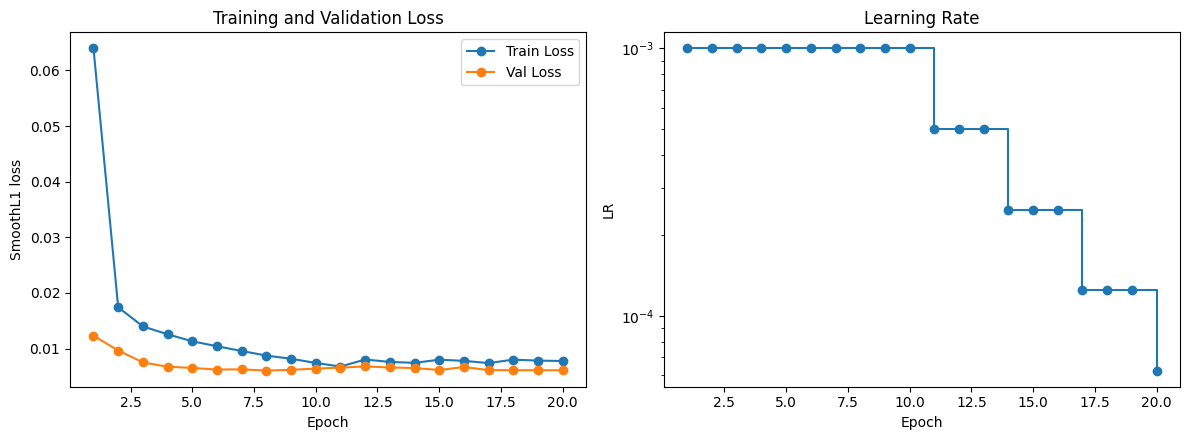

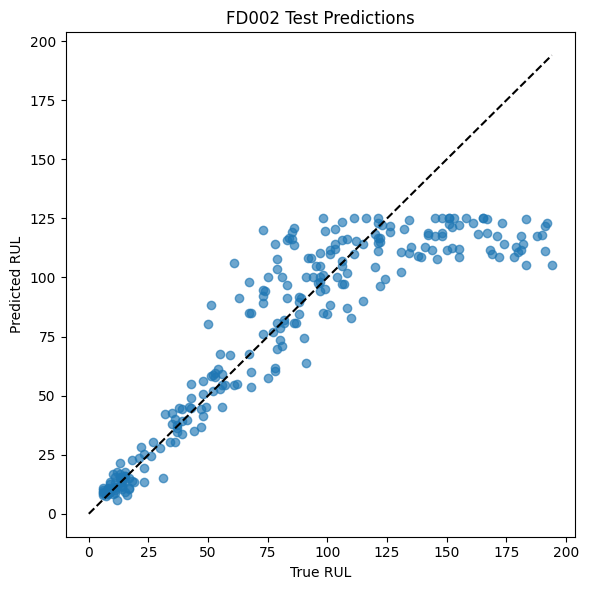

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train Loss")
axes[0].plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Val Loss")
axes[0].set_title("Training and Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("SmoothL1 loss")
axes[0].legend()

axes[1].step(history_df["epoch"], history_df["learning_rate"], where="post", marker="o")
axes[1].set_title("Learning Rate")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("LR")
axes[1].set_yscale("log")

fig.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(test_results["true_rul"], test_results["prediction_capped"], alpha=0.65)
line_max = max(float(test_results["true_rul"].max()), float(test_results["prediction_capped"].max()))
ax.plot([0, line_max], [0, line_max], linestyle="--", color="black")
ax.set_title("FD002 Test Predictions")
ax.set_xlabel("True RUL")
ax.set_ylabel("Predicted RUL")
fig.tight_layout()
plt.show()
